<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/LANL-logo.png" alt="LANL Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/prowess.png" alt="Prowess Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wildfire.png" alt="WildFire Logo" width="100"/>
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Fire-Ready Forests Data Challenge</h1>

# Sprint 3 - Tasks 1-2

**Team Name: HeatMappers** 

**Members:**

- Ansh Bhatnagar
- Jason Qin
- Jeronimo Adames-Baena
- Ishayu Ghosh

Use this notebook to report your work for Sprint 2. Add code and markdown cells as needed to report your solutions.

### Task 1

Using the `tls-metrics.ipynb` notebook as a reference, compare the trees inventories of a site different than Independence Lake. What do you think are the main reasons for any discrepancies between the two treelists? Include at least 1 figure.  

Text(0.5, 1.0, 'TLS vs Field Data')

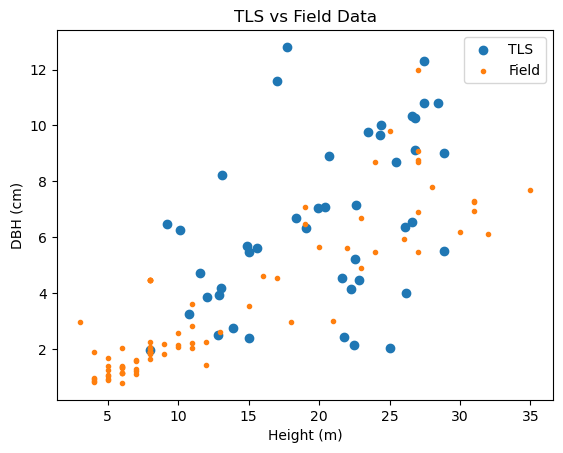

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plot_inventory = pd.read_csv("data/01_plot_identification.csv")
site_name = "SHA"
SHA_inventory = plot_inventory.loc[plot_inventory.site_name == site_name, ['inventory_id', 'plot_blk']]
SHA_sample = SHA_inventory.head()

tls_treelist = pd.read_csv("data/TLS_treelist.csv")
field_treelist = pd.read_csv("data/03_tree.csv")

tls_treelist_SHA = tls_treelist.merge(SHA_sample[['plot_blk']], on='plot_blk', how='inner')
field_treelist_SHA = field_treelist.merge(SHA_sample[['inventory_id']], on='inventory_id', how='inner')


fig, ax = plt.subplots()
plt.scatter(tls_treelist_SHA.H, tls_treelist_SHA.DBH/2.54, axes = ax, label = 'TLS')
plt.scatter(field_treelist_SHA.tree_ht, field_treelist_SHA.tree_dbh/10, axes = ax, marker = '.',label= 'Field')
plt.xlabel('Height (m)')
plt.ylabel('DBH (cm)')
plt.legend()
plt.title('TLS vs Field Data')

Discrepancies between the TLS and field tree inventories, as shown in the graph, is likely resulted from differences in how each method detects and measures trees. As we can see, TLS data tends to report higher DBH values than field measurements for trees of similar height, possibly due to TLS’s reliance on point cloud modeling, which can overestimate stem diameter when laser returns are affected by noise or partial occlusion. Moreover, the TLS data includes noticeably fewer small trees suggesting it may struggle to detect smaller trees. This limitation could result from occlusion by larger trees or reduced scan resolution near the forest floor. 

### Task 2

Can you refine these predictions? Try using a Machine Learning approach to estimate key tree metrics such as diameter, species, and crown base height. This time, select a different site of interest and compare your results with field observations.

In the example provided, we used the FastFuels treelist as the source for training data and compared the results against field-collected data. However, was this the best choice? As you approach this task, consider whether a different source—such as FIA data or the field-collected measurements—might serve as a more reliable training dataset. Think critically about the strengths and limitations of each dataset and justify your choice.

The primary goal of this task is to give you hands-on experience with different methods for predicting tree metrics. There is no single correct answer—this is an open-ended exploration. However, we encourage you to:

* Analyze correlations within your data
* Identify patterns that influence tree metric predictions
* Evaluate different training data sources to see which yields the most accurate estimates

Don't just run a model—dig deep into the data and make informed decisions along the way.

In [2]:
# Task 2 - Your code here

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ALS_treetops = pd.read_csv('data/ALS_treetops.csv')
field_treelist = pd.read_csv('data/03_tree.csv') # change away from FF dataset -> Field Data
#FF_treelist = pd.read_csv('FF_treelist_all.csv')
fia_ref_species_table = pd.read_csv('data/REF_SPECIES.csv')

field_treelist['site_name'] = field_treelist['inventory_id'].str.split('_').str[2]
field_treelist['HT'] = field_treelist['tree_ht']
field_treelist['DIA'] = field_treelist['tree_dbh']

# Investigating SHA site instead
site_name = 'tcu'

In [3]:
# counts by location -> take max for most available data

field_treelist.groupby('site_name').count()

,inventory_id,tree_id,tree_tag,tree_sp,tree_sp_scientific_name,tree_sp_vernacular_name,tree_status,tree_status_label,tree_dbh,tree_firedamage,...,tree_decay_class,tree_decay_class_label,treepost_scorch_m,treepost_scorch_per,treepost_torch_m,treepost_torch_per,treepost_bole_char_m,tree_notes,HT,DIA
site_name,,,,,,,,,,,,,,,,,,,,,
SDR,364,364,364,364,364,0,364,364,364,182,...,34,34,0,0,0,0,0,22,364,364
SHA,348,348,348,348,348,0,348,348,348,0,...,34,34,123,123,123,123,121,20,348,348
ind,358,358,358,358,358,0,358,358,358,0,...,83,83,45,45,45,45,45,18,358,358
puc,263,263,263,263,263,0,263,263,263,0,...,29,29,0,0,0,0,0,6,263,263
tcu,570,570,570,570,570,0,570,570,570,0,...,141,141,1,1,1,1,1,27,570,570
win,244,244,244,244,244,0,244,244,244,0,...,8,8,0,0,0,0,0,6,244,244


Model R^2: 0.53
Model RMSE: 18.83 inches


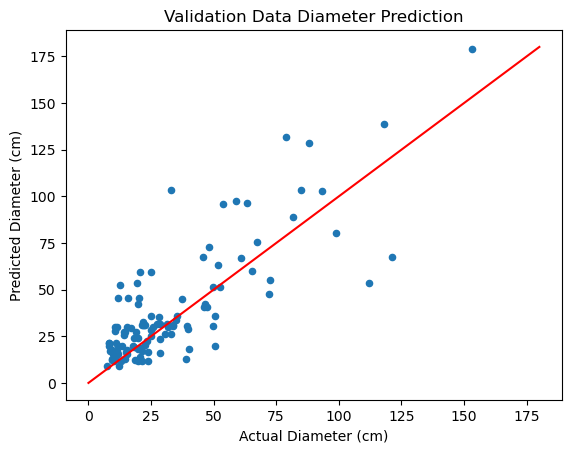

In [4]:
# Predict DBH from Height

ALS_treetops_filter = ALS_treetops[ALS_treetops.site_name == site_name]
field_treelist_filter = field_treelist[field_treelist.site_name == site_name]
ALS_treetops_filter = ALS_treetops_filter.rename(columns = {'height_m': 'HT'})
ALS_treetops_gdf = gpd.GeoDataFrame(ALS_treetops_filter, geometry = gpd.points_from_xy(ALS_treetops_filter.X_4326, ALS_treetops_filter.Y_4326), crs = 4326)
treelist = field_treelist_filter

independent_variables = ["HT"]
dependent_variable = "DIA"
include_variables = independent_variables + [dependent_variable]
trees_train, trees_test = train_test_split(treelist[include_variables].dropna(), test_size=0.2)

# Training the model
model_ht = RandomForestRegressor()
model_ht.fit(trees_train[independent_variables], trees_train[dependent_variable])
predicted_dbh_test = model_ht.predict(trees_test[independent_variables])
predicted_dbh = model_ht.predict(ALS_treetops_filter[independent_variables])
print(f"Model R^2: {model_ht.score(trees_test[independent_variables], trees_test[dependent_variable]):.2f}")
print(f"Model RMSE: {((model_ht.predict(trees_test[independent_variables]) - trees_test[dependent_variable])**2).mean()**0.5:.2f} inches")


# Plotting predicted diameter vs. the actual diameter.
fig, ax = plt.subplots()
trees_test["predicted_diameter"] = predicted_dbh_test
trees_test.plot.scatter(x="DIA", y="predicted_diameter", ax=ax)
upper_dia_limit = max(trees_test["DIA"].max(), trees_test["predicted_diameter"].max()) + 1
ax.plot([0, upper_dia_limit], [0, upper_dia_limit], color='red')
ax.set_xlabel("Actual Diameter (cm)")
ax.set_ylabel("Predicted Diameter (cm)")
ax.set_title("Validation Data Diameter Prediction")
plt.show()

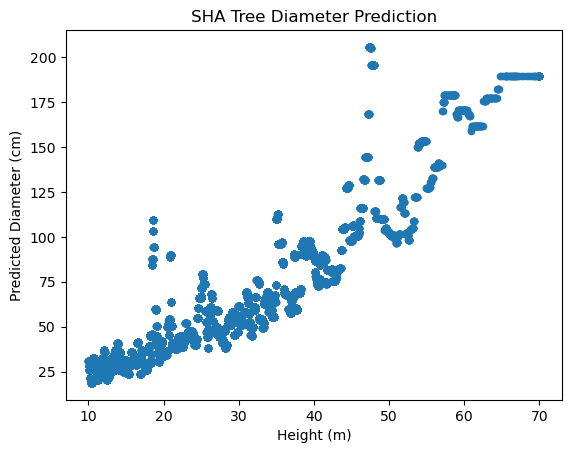

In [5]:
ALS_treetops_filter["predicted_diameter"] = predicted_dbh
fig, ax = plt.subplots()
ALS_treetops_filter.plot.scatter(x="HT", y="predicted_diameter", ax=ax)
ax.set_xlabel("Height (m)")
ax.set_ylabel("Predicted Diameter (cm)")
ax.set_title("SHA Tree Diameter Prediction")
plt.show()

In [6]:
# Predict SPCD From Height

fia_ref_species_table['scientific_name'] = fia_ref_species_table['GENUS'] + " " + fia_ref_species_table['SPECIES']
scientific_to_spcd = dict(zip(fia_ref_species_table['scientific_name'], fia_ref_species_table['SPCD']))
spcd_to_common_name = dict(zip(fia_ref_species_table['SPCD'], fia_ref_species_table['COMMON_NAME']))
treelist['SPCD'] = treelist['tree_sp_scientific_name'].map(scientific_to_spcd)

# Split into training and test sets
independent_variables = ["HT"]
dependent_variable = "SPCD"
include_variables = independent_variables + [dependent_variable]
trees_train, trees_test = train_test_split(treelist[include_variables].dropna(), test_size=0.2)
print(f"Training set size: {len(trees_train)}")
print(f"Test set size: {len(trees_test)}")

Training set size: 447
Test set size: 112


/tmp/ipykernel_736/1384268601.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treelist['SPCD'] = treelist['tree_sp_scientific_name'].map(scientific_to_spcd)


In [7]:
trees_test[dependent_variable].unique()

array([ 15.,  81., 117., 818., 321., 122.])

                      precision    recall  f1-score   support

           white fir       0.49      0.44      0.46        50
       incense-cedar       0.59      0.59      0.59        49
          sugar pine       0.50      0.71      0.59         7
      ponderosa pine       0.00      0.00      0.00         2
       giant sequoia       0.00      0.00      0.00         0
Rocky Mountain maple       0.00      0.00      0.00         1
California black oak       0.00      0.00      0.00         3

            accuracy                           0.50       112
           macro avg       0.23      0.25      0.23       112
        weighted avg       0.51      0.50      0.50       112



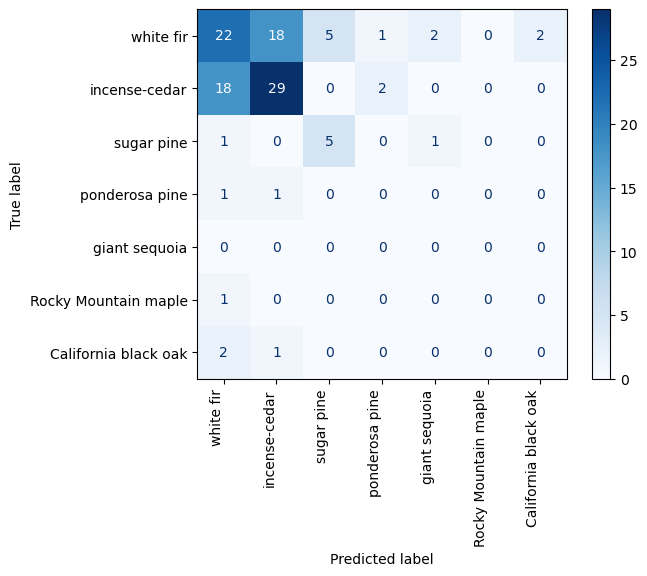

In [9]:
# Train the model
model_spcd = RandomForestClassifier()
model_spcd.fit(trees_train[independent_variables], trees_train[dependent_variable])

# Predict the model
predicted_spcd_test = model_spcd.predict(trees_test[independent_variables])
predicted_spcd = model_spcd.predict(ALS_treetops_filter[independent_variables])


# Evaluate classification accuracy
# Get all unique species from both true and predicted labels
unique_species = sorted(list(set(trees_test[dependent_variable]) | set(predicted_spcd_test)))

# Map species codes to readable names (fallback to "Unknown" if not mapped)
species_names = [spcd_to_common_name.get(spcd, f"Unknown ({spcd})") for spcd in unique_species]

# Generate classification report with matching labels and target names
report = classification_report(
    trees_test[dependent_variable],
    predicted_spcd_test,
    labels=unique_species,
    target_names=species_names,
    zero_division=0
)
print(report)

# Generate confusion matrix using same label order
cm = confusion_matrix(trees_test[dependent_variable], predicted_spcd_test, labels=unique_species)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_names)
display.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=90, ha='right')
plt.show()

/tmp/ipykernel_736/67966168.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treelist["CBH"] = treelist["tree_htlcb"]


Training set size: 386
Test set size: 43

Model R^2: 0.67
Model RMSE: 4.87 feet


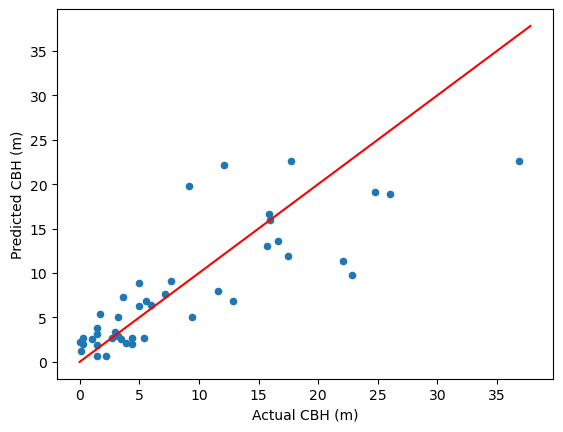

In [10]:
# crown base height from height

treelist["CBH"] = treelist["tree_htlcb"]
independent_variables = "HT"
dependent_variable = "CBH"
include_variables = independent_variables + dependent_variable
trees_train, trees_test = train_test_split(treelist[['HT', 'CBH']].dropna(), test_size=0.1)
print(f"Training set size: {len(trees_train)}")
print(f"Test set size: {len(trees_test)}")

# Train the model
model_cbh = RandomForestRegressor()
model_cbh.fit(trees_train[[independent_variables]], trees_train[dependent_variable])

# predict the model
predicted_cbh_test = model_cbh.predict(trees_test[[independent_variables]])
predicted_cbh = model_cbh.predict(ALS_treetops_filter[[independent_variables]])

# Evaluate model performance
print()
print(f"Model R^2: {model_cbh.score(trees_test[[independent_variables]], trees_test[dependent_variable]):.2f}")
print(f"Model RMSE: {((model_cbh.predict(trees_test[[independent_variables]]) - trees_test[dependent_variable])**2).mean()**0.5:.2f} feet")

# Compare the predicted CBH to the actual CBH.
fig, ax = plt.subplots()
trees_test["predicted_cbh"] = predicted_cbh_test
trees_test.plot.scatter(x="CBH", y="predicted_cbh", ax=ax)
upper_cbh_limit = max(trees_test["CBH"].max(), trees_test["predicted_cbh"].max()) + 1
ax.plot([0, upper_cbh_limit], [0, upper_cbh_limit], color='red')
ax.set_xlabel("Actual CBH (m)")
ax.set_ylabel("Predicted CBH (m)")
plt.show()

### Overall Analysis

As compared to the FastFuels tree list used in TL_w_ALS.ipynb, our model performance in this case utilizing field data is significantly worse, but this difference in performance makes sense. In the earlier stages of training this model, I printed out the groupby counts by location of the field data that we are using (03_tree.csv), and we can see that the number of data points we have in this situation is significantly less than the FF dataset, which had 1000+ points per site, whereas here the highest tally for a group was ~500. Furthermore, this field dataset relies more heavily on human measurement and calculation, as opposed to the other datasets which use technological methods to capture more large-scale data, this set is more of a collection of samples. I used the group with the highest value to ensure we had the most data available for an accurate model - but as we can see from our plots - the sheer fact that our datasets are significantly smaller makes it harder for the model to eliminate noise and find a more general trend. This particular location seems to be dominated by white fir, and as we can see in the correlation matrix, the model tends to incorrectly predict white fir a significant amount of times for the second most common tree species - incense cedar.

As mentioned above, sparisty of data was the biggest issue here. Looking at the graph of actual vs. predicted diameter, we can see how dispered the values for large diameters are, making it very difficult for our model to make accurate predictions. This same thing can be observed for the CBH prediction graph. Despite all of this, however, our model still does an adequate job, with an accuracy score above 70% in both cases, and an indication of a linear trend between height and DBH (at least for smaller values) which we also observed with our FF dataset.